In [78]:
import akshare as ak

sw_index_third_cons_df = ak.sw_index_third_cons(symbol="850111.SI")

HTTPError: HTTP Error 403: Forbidden

In [ ]:
info = ak.sw_index_third_info()

In [277]:
import pandas as pd
import numpy as np
from itertools import product
from lwpackage.lwfactors import *
from lwpackage.lwutils import *
from lwpackage.lwstats import *
# from lwpackage.factors import get_factor_value, get_future_ret, cross_sectional_norm
# from lwpackage.factors import get_grouped_ret_and_turnover_for_one_factor
from lwpackage.lwmodels import LightGBM
from lwpackage.lwdata import get_stock_price, get_stock_info

In [278]:
from lwpackage.lwdata import get_futures_continuous_contract_price
get_futures_continuous_contract_price()

,time,instrument_id,open,high,low,close,volume,position
0,2009-05-25,V0,6575.0,6630.0,6435.0,6490.0,107764,12278
1,2009-05-26,V0,6485.0,6540.0,6445.0,6460.0,38290,10562
2,2009-05-27,V0,6500.0,6535.0,6460.0,6485.0,34002,10346
3,2009-06-01,V0,6555.0,6595.0,6520.0,6570.0,26178,10352
4,2009-06-02,V0,6590.0,6590.0,6545.0,6555.0,13496,9388
...,...,...,...,...,...,...,...,...
170605,2024-02-02,LC0,99600.0,101500.0,99300.0,100150.0,71323,135549
170606,2024-02-05,LC0,100400.0,101250.0,99550.0,100450.0,45180,132983
170607,2024-02-06,LC0,100450.0,100650.0,96400.0,97150.0,110907,142239
170608,2024-02-07,LC0,97100.0,98350.0,97050.0,97650.0,42570,136452


In [2]:
fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate']
fc_freq = '1d'
instrument_type='stock'
start_time='20180101'
end_time='20200101'
transaction_period = None
rfr = True
ret_freq=30
portfolio_number=10
portfolio_method='longshort'
interest_method='simple'
fee=0.00025
risk_free_rate=True
n_jobs=5
path = '/Users/wenglongao/prep/data.pickle'
fc_name_with_param_list = []
for fc_name in fc_name_list:
    parameters = eval(fc_name).param_range
    fc_name_with_param_list += \
        [join_fc_name_and_parameter(fc_name, parameter) for parameter in iterdict(parameters)]

In [3]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'], 
                fc_freq = '1d',
                instrument_type='stock',
                start_time='20180101', 
                end_time='20200101', 
                ret_freq=30, 
                portfolio_number=10,
                portfolio_method='longshort',
                interest_method='simple',
                fee=0.00025,
                risk_free_rate=True,
                n_jobs=5)

In [4]:
bt.backtest()

/Users/wenglongao/anaconda3/envs/leoweng4.1/lib/python3.9/site-packages/lwpackage/lwfactors/factor_indicators.py:61: RuntimeWarning: invalid value encountered in double_scalars
  lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
/Users/wenglongao/anaconda3/envs/leoweng4.1/lib/python3.9/site-packages/lwpackage/lwfactors/factor_indicators.py:61: RuntimeWarning: invalid value encountered in double_scalars
  lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
/Users/wenglongao/anaconda3/envs/leoweng4.1/lib/python3.9/site-packages/lwpackage/lwfactors/factor_indicators.py:61: RuntimeWarning: invalid value encountered in double_scalars
  lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
/Users/wenglongao/anaconda3/envs/leoweng4.1/lib/python3.9/site-packages/lwpackage/lwfactors/factor_indicators.py:61: RuntimeWarning: invalid value encountered in double_scalars
  lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
/Users/wenglongao/anaconda3/envs/leoweng4.1/lib/python3.9/site-packages/lwpackage/lwfactors/fact

In [43]:
def get_grouped_ret_and_turnover_for_one_factor(Data: pd.DataFrame,
                                                fc_col: str,
                                                portfolio_number=10,
                                                portfolio_method: str = 'longshort',
                                                fc_freq: str = '1d',
                                                fee: float = 0.00025):
    """
    Get the ret, net ret, instrument count, turnover data for one factor.

    :param Data: a dataframe with columns 'time', 'instrument_id', fc_name, 'ret'
    :param fc_col:
    :param portfolio_number:
    :param portfolio_method:
    :param fc_freq:
    :param fee:
    :return: daily-freq data of ret, net ret, instrument count, turnover
    """
    assert fc_freq in ['1m', '5m', '1d'], f'Only support 1m, 5m or 1d fc_freq, but got {fc_freq} instead.'
    assert portfolio_number > 1, f'Portfolio number should be larger than 1, but got {portfolio_number} instead.'
    for col in ['time', 'instrument_id', fc_col, 'future_ret']:
        assert col in Data.columns, f'Data does not contain column {col}.'

    df = Data.copy()
    # 此处需要特别注意nan value的处理，即future ret列中可能包含nan值。
    # 1. 如果某个时间截面上部分股票的future ret的值为nan，就剔除这些股票，用剩下的股票进行分组。
    # 2. 如果某个时间截面上部分股票的fc_col的值为nan（不存在因子值），也剔除这些股票，用剩下的股票进行分组。
    # 3. 如果某个时间截面不存在股票数据，或者剔除后的有效标的数量小于portfolio number，则不进行分组。
    # 综上考虑，在一开始求解的时候先对fc_col和future_ret dropna，再将有效标的数量小于portfolio number的时间戳删除后进行计算即可。
    # 注意最后需要将计算的结果和完整的时间戳merge，如果最终结果存在nan，则说明这个时间戳我们无法进行计算。

    df = df.dropna(subset=[fc_col, 'future_ret'])
    count = df.groupby('time').size()
    invaild_time_idx = count[count < portfolio_number].index.to_list()
    df = df[~df['time'].isin(invaild_time_idx)]

    df = df.set_index(['time', 'instrument_id'])
    df['quantile_0'] = float('-inf')
    for i in range(1, portfolio_number):
        df[f'quantile_{i}'] = df.groupby('time')[fc_col].transform(lambda x: x.quantile(i / portfolio_number))
    df[f'quantile_{portfolio_number}'] = float('inf')

    df_gross_ret, df_n, df_turnover = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    for i in range(portfolio_number):

        df_gross_ret[f'{fc_col} {i + 1}'] = df.groupby('time').apply(
            lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
                        (x[fc_col] < x[f'quantile_{i + 1}'])) * x['future_ret']).sum() / (
                              (x[fc_col] > x[f'quantile_{i}']) &
                              (x[fc_col] < x[f'quantile_{i + 1}'])).sum(), include_groups=False)

        df_n[f'{fc_col} {i + 1}'] = df.groupby('time').apply(
            lambda x: ((x[fc_col] > x[f'quantile_{i}']) &
                       (x[fc_col] < x[f'quantile_{i + 1}'])).sum(), include_groups=False)

        turnover_arr = df.groupby('time', as_index=False).apply(lambda x: (x[fc_col] > x[f'quantile_{i}']) &
                                                                          (x[fc_col] < x[f'quantile_{i + 1}']),
                                                                include_groups=False).droplevel(0)
        turnover_arr = (turnover_arr.unstack() * 1).astype(float).fillna(0)
        turnover_arr = turnover_arr.apply(lambda x: x / df_n[f'{fc_col} {i + 1}'])
        turnover_arr = turnover_arr.diff().abs().sum(axis=1)

        df_turnover[f'{fc_col} {i + 1}'] = turnover_arr

    df_gross_ret[f'{fc_col} {portfolio_number}-1'] = (df_gross_ret[f'{fc_col} {portfolio_number}'] - df_gross_ret[
        f'{fc_col} {1}']) / 2
    # Assume that at any time, the long portfolio and short portfolio do not contain replicated instruments.
    df_turnover[f'{fc_col} {portfolio_number}-1'] = \
        (df_turnover[f'{fc_col} {portfolio_number}'] + df_turnover[f'{fc_col} {1}'])

    # When data is not day-freq, we calculate the minute-freq ret and then aggregate it.
    if fc_freq != '1d':
        df_gross_ret = df_gross_ret.reset_index()
        df_gross_ret['time'] = pd.to_datetime(df_gross_ret['time']).dt.date
        df_gross_ret = df_gross_ret.groupby('time').sum()

        df_turnover = df_turnover.reset_index()
        df_turnover['time'] = pd.to_datetime(df_turnover['time']).dt.date
        df_turnover = df_turnover.groupby('time').sum()

        df_n = df_n.reset_index()
        df_n['time'] = pd.to_datetime(df_n['time']).dt.date
        df_n = df_n.groupby('time').mean()

    # net ret = gross ret - turnover * fee
    df_net_ret = df_gross_ret - df_turnover * fee

    if portfolio_method == 'longshort':
        df_gross_ret['ret'] = df_gross_ret[f'{fc_col} {portfolio_number}-1']
        df_net_ret['ret'] = df_net_ret[f'{fc_col} {portfolio_number}-1']
        df_turnover['ret'] = df_turnover[f'{fc_col} {portfolio_number}-1']

    elif portfolio_method == 'long_only':
        df_gross_ret['ret'] = df_gross_ret[f'{fc_col} {portfolio_number}']
        df_net_ret['ret'] = df_net_ret[f'{fc_col} {portfolio_number}']
        df_turnover['ret'] = df_turnover[f'{fc_col} {portfolio_number}']

    else:
        raise NotImplementedError(f'Do not support method {portfolio_method}.')

    df_gross_ret = df_gross_ret.reset_index()
    df_gross_ret['time'] = pd.to_datetime(df_gross_ret['time']).dt.date
    df_gross_ret = df_gross_ret.groupby('time').sum()

    # These four dataframe should not contain any nan values according to the above procedure.
    # 如果某一个时间截面的数据无法计算，df中就直接不包含这一个时间截面，而不是将这个时间截面的计算结果设置为nan
    return df_gross_ret, df_net_ret, df_n, df_turnover

In [45]:
df_gross_ret, df_net_ret, df_n, df_turnover = get_grouped_ret_and_turnover_for_one_factor(
    bt.data, bt.fc_name_with_param_list[0])

In [46]:
df_gross_ret

,fac_cumret_1_50 1,fac_cumret_1_50 2,fac_cumret_1_50 3,fac_cumret_1_50 4,fac_cumret_1_50 5,fac_cumret_1_50 6,fac_cumret_1_50 7,fac_cumret_1_50 8,fac_cumret_1_50 9,fac_cumret_1_50 10,fac_cumret_1_50 10-1,ret
time,,,,,,,,,,,,
2018-01-03,-0.162053,-0.106622,-0.111126,-0.130473,-0.118689,-0.131483,-0.120294,-0.127207,-0.135588,-0.099702,0.031176,0.031176
2018-01-04,-0.150748,-0.136676,-0.123114,-0.111189,-0.115296,-0.128491,-0.118782,-0.130369,-0.114679,-0.094606,0.028071,0.028071
2018-01-05,-0.137442,-0.124726,-0.113746,-0.112514,-0.100484,-0.112278,-0.105915,-0.109732,-0.109826,-0.078419,0.029512,0.029512
2018-01-08,-0.122702,-0.119339,-0.112471,-0.092011,-0.100202,-0.108926,-0.089897,-0.089858,-0.092785,-0.076342,0.023180,0.023180
2018-01-09,-0.123781,-0.117781,-0.108427,-0.109678,-0.101039,-0.104437,-0.093548,-0.096270,-0.090139,-0.102113,0.010834,0.010834
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-12,0.116929,0.064993,0.051378,0.058425,0.057347,0.050638,0.054769,0.068995,0.063991,0.057333,-0.029798,-0.029798
2019-11-13,0.122098,0.066283,0.061576,0.062740,0.064653,0.047515,0.069188,0.073518,0.071355,0.057701,-0.032199,-0.032199
2019-11-14,0.122466,0.078820,0.065705,0.060231,0.068420,0.059148,0.063448,0.081333,0.074329,0.045226,-0.038620,-0.038620


In [ ]:
bt.performance_dc[fc_name]['daily_gross_ret']

In [47]:
fc_name = bt.fc_name_with_param_list[0]
fc_name

'fac_cumret_1_50'

In [73]:
data1 = bt.data.copy()

In [ ]:
data1.groupby('time')['close']

In [58]:
data1['future_ret1'] = data1.groupby('instrument_id')['close'].transform(lambda x: x.pct_change())

In [ ]:
# 每日调仓，月底调仓

In [69]:
bt.data

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,-0.335598,-0.335598,NaN,NaN,5.7525,-0.151828
1,2018-01-02,603926,27.00,27.35,27.00,27.30,7995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.1625,-0.156068
2,2018-01-02,300324,14.56,14.67,14.42,14.51,53695,NaN,NaN,NaN,NaN,NaN,NaN,-0.324868,-0.324868,NaN,NaN,14.5400,0.093036
3,2018-01-02,600243,6.86,6.89,6.81,6.88,9416,NaN,NaN,NaN,NaN,NaN,NaN,-0.341607,-0.341607,NaN,NaN,6.8600,-0.123333
4,2018-01-02,600741,29.69,29.70,27.60,28.33,346317,NaN,NaN,NaN,NaN,NaN,NaN,-0.395254,-0.395254,NaN,NaN,28.8300,-0.099530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253421,2019-12-31,300605,12.80,13.08,12.68,12.76,25394,-0.238326,-0.163342,-0.220543,-0.177324,-0.281546,-0.179633,-0.100471,-0.541312,0.782503,0.784770,12.8300,NaN
1253422,2019-12-31,603311,11.13,11.26,11.05,11.18,11332,0.244698,0.047732,0.285340,0.070534,0.310896,0.080795,-0.258357,-0.358106,-0.007444,-0.096426,11.1550,NaN
1253423,2019-12-31,000880,7.76,7.86,7.74,7.83,9107,-0.187058,-0.192428,-0.184853,-0.199816,-0.194598,-0.231739,-0.201260,-0.397232,1.572450,1.225367,7.7975,NaN
1253424,2019-12-31,600076,4.30,4.42,4.29,4.39,185037,-0.030087,-0.096852,-0.045573,-0.100833,-0.060910,-0.105013,-0.017982,-0.420399,0.782503,0.344172,4.3500,NaN


In [72]:
data1

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret,future_ret1
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,-0.335598,-0.335598,NaN,NaN,5.7525,-0.151828,NaN
1,2018-01-02,603926,27.00,27.35,27.00,27.30,7995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.1625,-0.156068,NaN
2,2018-01-02,300324,14.56,14.67,14.42,14.51,53695,NaN,NaN,NaN,NaN,NaN,NaN,-0.324868,-0.324868,NaN,NaN,14.5400,0.093036,NaN
3,2018-01-02,600243,6.86,6.89,6.81,6.88,9416,NaN,NaN,NaN,NaN,NaN,NaN,-0.341607,-0.341607,NaN,NaN,6.8600,-0.123333,NaN
4,2018-01-02,600741,29.69,29.70,27.60,28.33,346317,NaN,NaN,NaN,NaN,NaN,NaN,-0.395254,-0.395254,NaN,NaN,28.8300,-0.099530,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253421,2019-12-31,300605,12.80,13.08,12.68,12.76,25394,-0.238326,-0.163342,-0.220543,-0.177324,-0.281546,-0.179633,-0.100471,-0.541312,0.782503,0.784770,12.8300,NaN,-0.010853
1253422,2019-12-31,603311,11.13,11.26,11.05,11.18,11332,0.244698,0.047732,0.285340,0.070534,0.310896,0.080795,-0.258357,-0.358106,-0.007444,-0.096426,11.1550,NaN,0.006301
1253423,2019-12-31,000880,7.76,7.86,7.74,7.83,9107,-0.187058,-0.192428,-0.184853,-0.199816,-0.194598,-0.231739,-0.201260,-0.397232,1.572450,1.225367,7.7975,NaN,0.009021
1253424,2019-12-31,600076,4.30,4.42,4.29,4.39,185037,-0.030087,-0.096852,-0.045573,-0.100833,-0.060910,-0.105013,-0.017982,-0.420399,0.782503,0.344172,4.3500,NaN,0.018561


In [94]:
data1['future_ret'].max() * 4 * 60 * 240

57600.0

In [106]:
data1['future_ret'].mean() * 4 * 60 * 240

-16.20090530560408

In [112]:
data1['future_ret'] = data1.groupby('instrument_id')['close'].transform(lambda x: x.pct_change())

In [114]:
def get_grouped_ret_and_turnover_for_one_factor(Data: pd.DataFrame,
                                                fc_col: str,
                                                portfolio_number=10,
                                                portfolio_method: str = 'longshort',
                                                fc_freq: str = '1d',
                                                fee: float = 0.00025):
    """
    Get the ret, net ret, instrument count, turnover data for one factor.

    :param Data: a dataframe with columns 'time', 'instrument_id', fc_name, 'ret'
    :param fc_col:
    :param portfolio_number:
    :param portfolio_method:
    :param fc_freq:
    :param fee:
    :return: daily-freq data of ret, net ret, instrument count, turnover
    """
    assert fc_freq in ['1m', '5m', '1d'], f'Only support 1m, 5m or 1d fc_freq, but got {fc_freq} instead.'
    assert portfolio_number > 1, f'Portfolio number should be larger than 1, but got {portfolio_number} instead.'
    for col in ['time', 'instrument_id', fc_col, 'future_ret']:
        assert col in Data.columns, f'Data does not contain column {col}.'

    df = Data.copy()
    # 此处需要特别注意nan value的处理，即future ret列中可能包含nan值。
    # 1. 如果某个时间截面上部分股票的future ret的值为nan，就剔除这些股票，用剩下的股票进行分组。
    # 2. 如果某个时间截面上部分股票的fc_col的值为nan（不存在因子值），也剔除这些股票，用剩下的股票进行分组。
    # 3. 如果某个时间截面不存在股票数据，或者剔除后的有效标的数量小于portfolio number，则不进行分组。
    # 综上考虑，在一开始求解的时候先对fc_col和future_ret dropna，再将有效标的数量小于portfolio number的时间戳删除后进行计算即可。
    # 注意最后需要将计算的结果和完整的时间戳merge，如果最终结果存在nan，则说明这个时间戳我们无法进行计算。

    df = df.dropna(subset=[fc_col, 'future_ret'])
    count = df.groupby('time').size()
    invaild_time_idx = count[count < portfolio_number].index.to_list()
    df = df[~df['time'].isin(invaild_time_idx)]

    df = df.set_index(['time', 'instrument_id'])
    df['quantile_0'] = float('-inf')
    for i in range(1, portfolio_number):
        df[f'quantile_{i}'] = df.groupby('time')[fc_col].transform(lambda x: x.quantile(i / portfolio_number))
    df[f'quantile_{portfolio_number}'] = float('inf')

    df_gross_ret, df_n, df_turnover = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    for i in range(portfolio_number):

        df_gross_ret[f'{fc_col} {i + 1}'] = df.groupby('time').apply(
            lambda x: (((x[fc_col] > x[f'quantile_{i}']) &
                        (x[fc_col] < x[f'quantile_{i + 1}'])) * x['future_ret']).sum() / (
                              (x[fc_col] > x[f'quantile_{i}']) &
                              (x[fc_col] < x[f'quantile_{i + 1}'])).sum(), include_groups=False)

        df_n[f'{fc_col} {i + 1}'] = df.groupby('time').apply(
            lambda x: ((x[fc_col] > x[f'quantile_{i}']) &
                       (x[fc_col] < x[f'quantile_{i + 1}'])).sum(), include_groups=False)

        turnover_arr = df.groupby('time', as_index=False).apply(lambda x: (x[fc_col] > x[f'quantile_{i}']) &
                                                                          (x[fc_col] < x[f'quantile_{i + 1}']),
                                                                include_groups=False).droplevel(0)
        turnover_arr = (turnover_arr.unstack() * 1).astype(float).fillna(0)
        turnover_arr = turnover_arr.apply(lambda x: x / df_n[f'{fc_col} {i + 1}'])
        turnover_arr = turnover_arr.diff().abs().sum(axis=1)

        df_turnover[f'{fc_col} {i + 1}'] = turnover_arr

    df_gross_ret[f'{fc_col} {portfolio_number}-1'] = (df_gross_ret[f'{fc_col} {portfolio_number}'] - df_gross_ret[
        f'{fc_col} {1}']) / 2
    # Assume that at any time, the long portfolio and short portfolio do not contain replicated instruments.
    df_turnover[f'{fc_col} {portfolio_number}-1'] = \
        (df_turnover[f'{fc_col} {portfolio_number}'] + df_turnover[f'{fc_col} {1}'])

    # When data is not day-freq, we calculate the minute-freq ret and then aggregate it.
    if fc_freq != '1d':
        df_gross_ret = df_gross_ret.reset_index()
        df_gross_ret['time'] = pd.to_datetime(df_gross_ret['time']).dt.date
        df_gross_ret = df_gross_ret.groupby('time').sum()

        df_turnover = df_turnover.reset_index()
        df_turnover['time'] = pd.to_datetime(df_turnover['time']).dt.date
        df_turnover = df_turnover.groupby('time').sum()

        df_n = df_n.reset_index()
        df_n['time'] = pd.to_datetime(df_n['time']).dt.date
        df_n = df_n.groupby('time').mean()

    # net ret = gross ret - turnover * fee
    df_net_ret = df_gross_ret - df_turnover * fee

    if portfolio_method == 'longshort':
        df_gross_ret['ret'] = df_gross_ret[f'{fc_col} {portfolio_number}-1']
        df_net_ret['ret'] = df_net_ret[f'{fc_col} {portfolio_number}-1']
        df_turnover['ret'] = df_turnover[f'{fc_col} {portfolio_number}-1']

    elif portfolio_method == 'long_only':
        df_gross_ret['ret'] = df_gross_ret[f'{fc_col} {portfolio_number}']
        df_net_ret['ret'] = df_net_ret[f'{fc_col} {portfolio_number}']
        df_turnover['ret'] = df_turnover[f'{fc_col} {portfolio_number}']

    else:
        raise NotImplementedError(f'Do not support method {portfolio_method}.')

    df_gross_ret = df_gross_ret.reset_index()
    df_gross_ret['time'] = pd.to_datetime(df_gross_ret['time']).dt.date
    df_gross_ret = df_gross_ret.groupby('time').sum()

    # These four dataframe should not contain any nan values according to the above procedure.
    # 如果某一个时间截面的数据无法计算，df中就直接不包含这一个时间截面，而不是将这个时间截面的计算结果设置为nan
    return df_gross_ret, df_net_ret, df_n, df_turnover

In [115]:
df_gross_ret, df_net_ret, df_n, df_turnover = get_grouped_ret_and_turnover_for_one_factor(data1, 'fac_cumret_1_50')

In [130]:
df_turnover

,fac_cumret_1_50 1,fac_cumret_1_50 2,fac_cumret_1_50 3,fac_cumret_1_50 4,fac_cumret_1_50 5,fac_cumret_1_50 6,fac_cumret_1_50 7,fac_cumret_1_50 8,fac_cumret_1_50 9,fac_cumret_1_50 10,fac_cumret_1_50 10-1,ret
time,,,,,,,,,,,,
2018-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-01-04,0.771784,1.583333,1.650000,1.575000,1.575000,1.741667,1.625000,1.733333,1.666667,0.987552,1.759336,1.759336
2018-01-05,0.788382,1.300000,1.394191,1.433333,1.450000,1.516667,1.475000,1.518672,1.483333,0.771784,1.560166,1.560166
2018-01-08,0.785124,1.311203,1.443983,1.551867,1.684647,1.585062,1.543568,1.510373,1.269710,0.570248,1.355372,1.355372
2018-01-09,0.545455,1.112033,1.327801,1.394191,1.485477,1.535270,1.454545,1.302905,1.153527,0.504132,1.049587,1.049587
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-25,0.411552,0.862319,0.963768,0.971014,1.072464,0.971014,0.920290,0.717391,0.521739,0.209386,0.620939,0.620939
2019-12-26,0.304348,0.770909,1.040000,1.047273,1.003636,1.032727,0.865455,0.789855,0.574545,0.239130,0.543478,0.543478
2019-12-27,0.418773,0.862319,1.000000,1.032491,1.057971,1.036232,0.895307,0.710145,0.500000,0.216606,0.635379,0.635379


In [141]:
df_gross_ret['ret'].mean() * 240 / (df_gross_ret['ret'].std() * np.sqrt(240))

19.91458106284215

In [126]:
df_gross_ret.loc[df_gross_ret['ret'] > 0]

,fac_cumret_1_50 1,fac_cumret_1_50 2,fac_cumret_1_50 3,fac_cumret_1_50 4,fac_cumret_1_50 5,fac_cumret_1_50 6,fac_cumret_1_50 7,fac_cumret_1_50 8,fac_cumret_1_50 9,fac_cumret_1_50 10,fac_cumret_1_50 10-1,ret
time,,,,,,,,,,,,
2018-01-03,-0.019852,-0.005409,-0.001613,0.001699,0.004521,0.007186,0.010303,0.014347,0.020943,0.051413,0.035632,0.035632
2018-01-04,-0.016998,-0.008969,-0.004677,-0.003829,-0.001775,-0.000606,0.002017,0.004064,0.010064,0.033877,0.025438,0.025438
2018-01-05,-0.017774,-0.008133,-0.003981,-0.003141,0.000405,0.000773,0.002653,0.005406,0.009033,0.023852,0.020813,0.020813
2018-01-08,-0.016871,-0.008292,-0.005495,-0.005805,-0.002641,0.000541,0.002072,0.006511,0.011804,0.030871,0.023871,0.023871
2018-01-09,-0.011247,-0.005399,-0.003454,-0.002778,-0.002148,-0.002311,0.000328,0.002193,0.007603,0.022878,0.017062,0.017062
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,0.013780,0.012289,0.013148,0.013624,0.012667,0.014828,0.016762,0.016218,0.022472,0.028064,0.007142,0.007142
2019-12-25,-0.002474,-0.000913,0.000021,0.000553,-0.001479,0.002925,0.003400,0.003868,0.007016,0.017627,0.010051,0.010051
2019-12-26,0.004336,0.005822,0.005951,0.007214,0.008018,0.007631,0.011213,0.010506,0.011346,0.021419,0.008542,0.008542


<Axes: xlabel='time'>

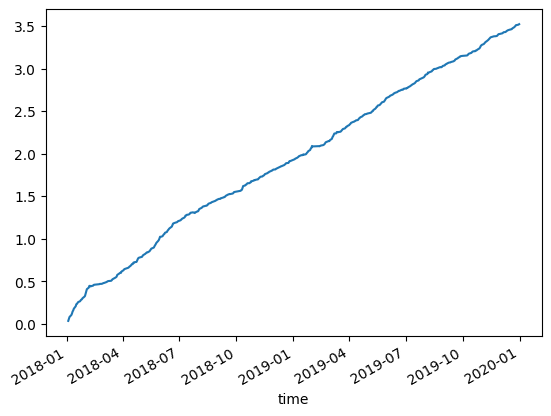

In [123]:
df_net_ret['ret'].cumsum().plot()

In [113]:
data1

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,-0.335598,-0.335598,NaN,NaN,5.7525,NaN
2,2018-01-02,300324,14.56,14.67,14.42,14.51,53695,NaN,NaN,NaN,NaN,NaN,NaN,-0.324868,-0.324868,NaN,NaN,14.5400,NaN
3,2018-01-02,600243,6.86,6.89,6.81,6.88,9416,NaN,NaN,NaN,NaN,NaN,NaN,-0.341607,-0.341607,NaN,NaN,6.8600,NaN
4,2018-01-02,600741,29.69,29.70,27.60,28.33,346317,NaN,NaN,NaN,NaN,NaN,NaN,-0.395254,-0.395254,NaN,NaN,28.8300,NaN
5,2018-01-02,600018,6.69,6.83,6.66,6.76,488880,NaN,NaN,NaN,NaN,NaN,NaN,0.024928,0.024928,NaN,NaN,6.7350,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253422,2019-12-31,603311,11.13,11.26,11.05,11.18,11332,0.244698,0.047732,0.285340,0.070534,0.310896,0.080795,-0.258357,-0.358106,-0.007444,-0.096426,11.1550,0.006301
1252041,2019-12-31,002665,3.37,3.39,3.35,3.36,240117,-0.210691,-0.230322,-0.213428,-0.174896,-0.206197,-0.141183,-0.536788,-0.332031,-0.797391,-0.096426,3.3675,-0.002967
1253415,2019-12-31,300715,20.47,20.86,20.47,20.81,11392,-0.371323,-0.066380,-0.395280,-0.048027,-0.300884,0.021091,-0.602864,-0.814511,-0.007444,-0.096426,20.6525,0.010194
1253416,2019-12-31,002331,9.87,9.97,9.81,9.87,12865,-0.347256,-0.155871,-0.308279,-0.143380,-0.318802,-0.162598,0.431623,-0.069345,0.782503,0.784770,9.8800,-0.002022


In [110]:
bt.performance_dc['fac_cumret']

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,-0.335598,-0.335598,NaN,NaN,5.7525,-0.151828
1,2018-01-02,603926,27.00,27.35,27.00,27.30,7995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.1625,-0.156068
2,2018-01-02,300324,14.56,14.67,14.42,14.51,53695,NaN,NaN,NaN,NaN,NaN,NaN,-0.324868,-0.324868,NaN,NaN,14.5400,0.093036
3,2018-01-02,600243,6.86,6.89,6.81,6.88,9416,NaN,NaN,NaN,NaN,NaN,NaN,-0.341607,-0.341607,NaN,NaN,6.8600,-0.123333
4,2018-01-02,600741,29.69,29.70,27.60,28.33,346317,NaN,NaN,NaN,NaN,NaN,NaN,-0.395254,-0.395254,NaN,NaN,28.8300,-0.099530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253421,2019-12-31,300605,12.80,13.08,12.68,12.76,25394,-0.238326,-0.163342,-0.220543,-0.177324,-0.281546,-0.179633,-0.100471,-0.541312,0.782503,0.784770,12.8300,NaN
1253422,2019-12-31,603311,11.13,11.26,11.05,11.18,11332,0.244698,0.047732,0.285340,0.070534,0.310896,0.080795,-0.258357,-0.358106,-0.007444,-0.096426,11.1550,NaN
1253423,2019-12-31,000880,7.76,7.86,7.74,7.83,9107,-0.187058,-0.192428,-0.184853,-0.199816,-0.194598,-0.231739,-0.201260,-0.397232,1.572450,1.225367,7.7975,NaN
1253424,2019-12-31,600076,4.30,4.42,4.29,4.39,185037,-0.030087,-0.096852,-0.045573,-0.100833,-0.060910,-0.105013,-0.017982,-0.420399,0.782503,0.344172,4.3500,NaN


In [107]:
data1['future_ret'].mean()

-0.000281265717111182

In [101]:
data1.loc[data1['future_ret'] == data1['future_ret'].max()]

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
14253,2018-01-09,835985,4.40,8.80,3.30,8.80,220,17.392369,17.392369,-5.733489,-5.733489,4.846399,4.846399,-0.304985,-0.304985,NaN,NaN,6.325,1.0
19081,2018-01-11,838030,4.00,4.00,4.00,4.00,1000,44.377633,44.377633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,1.0
19651,2018-01-12,830832,3.45,6.20,3.45,6.20,30,7.855095,7.855095,6.014032,6.014032,7.910892,7.910892,-0.677433,-0.677433,NaN,NaN,4.825,1.0
20475,2018-01-12,832885,5.00,5.00,5.00,5.00,10,15.272940,15.272940,20.004408,20.004408,20.282246,20.282246,NaN,NaN,NaN,NaN,5.000,1.0
129658,2018-03-26,833346,3.00,3.00,3.00,3.00,20,-3.314088,-3.376244,-30.305355,-30.336120,-36.411154,-36.420046,NaN,NaN,NaN,NaN,3.000,1.0
182019,2018-04-26,833346,5.98,5.98,5.98,5.98,10,17.372070,18.838142,8.961181,9.835634,7.760357,8.429704,NaN,NaN,NaN,NaN,5.980,1.0
255398,2018-06-12,833230,4.00,4.00,4.00,4.00,100,32.636156,33.930275,30.400461,32.058297,30.823879,32.481228,NaN,NaN,NaN,NaN,4.000,1.0
279988,2018-06-27,834639,2.02,2.02,2.02,2.02,390,0.131402,-0.006150,-1.921273,-2.075956,-2.519230,-2.673348,NaN,NaN,-0.613182,NaN,2.020,1.0
330524,2018-07-25,833429,3.24,3.24,3.24,3.24,10,-5.436868,-5.940362,-3.133448,-3.394527,-8.504072,-8.882032,NaN,NaN,NaN,NaN,3.240,1.0
345124,2018-08-02,834599,1.02,1.02,1.02,1.02,80010,34.608964,36.715306,28.668936,30.710745,23.389679,25.121202,NaN,NaN,NaN,NaN,1.020,1.0


In [108]:
data1.loc[data1['instrument_id'] == '833346']['future_ret'].mean()

0.17484179775609177

In [166]:
data2 = data1.loc[data1['instrument_id'] == '600018']
data2['future_ret'] /= 240
(data2['future_ret'] + 1).prod() - 1

-0.00019639287306205677

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
5,2018-01-02,600018,6.69,6.83,6.66,6.76,488880,NaN,NaN,NaN,NaN,NaN,NaN,0.024928,0.024928,NaN,NaN,6.7350,NaN
4192,2018-01-03,600018,6.78,6.94,6.78,6.86,583091,0.319482,0.319482,NaN,NaN,NaN,NaN,0.032106,0.032106,NaN,NaN,6.8400,0.000062
6411,2018-01-04,600018,6.88,7.55,6.75,7.53,858635,3.300209,3.300209,3.359385,3.359385,NaN,NaN,0.144972,0.144972,NaN,NaN,7.1775,0.000407
8793,2018-01-05,600018,7.20,7.37,7.14,7.16,1044919,1.460268,1.460268,2.920467,2.920467,1.402612,1.402612,0.039392,0.039392,NaN,NaN,7.2175,-0.000205
11453,2018-01-08,600018,7.15,7.28,7.00,7.18,577882,1.152950,1.152950,1.410624,1.410624,1.324328,1.324328,-0.060351,-0.060351,NaN,NaN,7.1525,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240185,2019-12-25,600018,5.70,5.70,5.65,5.67,147668,-0.205876,-0.500115,-0.189485,-0.489921,-0.176494,-0.501298,-0.421717,-0.717756,-0.517152,-0.572671,5.6800,-0.000022
1243879,2019-12-26,600018,5.68,5.69,5.65,5.68,168928,-0.108714,-0.191479,-0.076416,-0.137303,-0.233188,-0.546379,-0.456314,-0.726961,-0.019882,-0.636972,5.6750,0.000007
1246791,2019-12-27,600018,5.68,5.74,5.67,5.70,261345,-0.210515,-0.613411,-0.268282,-0.643975,-0.256942,-0.623387,-0.349087,-0.669432,0.404226,-0.252836,5.6975,0.000015
1250193,2019-12-30,600018,5.69,5.76,5.63,5.71,304324,-0.267049,-0.663852,-0.236917,-0.628944,-0.272194,-0.653886,-0.299677,-0.663371,0.602075,-0.218074,5.6975,0.000007


In [189]:
# 收益率平均按照年化10%计算
np.random.random(100)

array([0.00089097, 0.00692911, 0.00063996, 0.00247248, 0.00911235,
       0.00993276, 0.00862068, 0.00030632, 0.00672718, 0.00623491,
       0.00177899, 0.00699237, 0.00823019, 0.00932956, 0.00937097,
       0.00665008, 0.0025196 , 0.00758883, 0.00888293, 0.00698839,
       0.00821546, 0.00853992, 0.00359908, 0.00491919, 0.00864152,
       0.00618887, 0.00722683, 0.00775951, 0.00221227, 0.00966626,
       0.00337414, 0.00118108, 0.00689364, 0.00048146, 0.00910437,
       0.00776711, 0.00938342, 0.00925806, 0.00652703, 0.00827911,
       0.00548396, 0.00718176, 0.00307076, 0.00874854, 0.00690489,
       0.00789525, 0.00452904, 0.00366329, 0.00829903, 0.00350257,
       0.00796595, 0.00063582, 0.00706274, 0.0001383 , 0.00451692,
       0.00217531, 0.00192246, 0.00121153, 0.00867943, 0.00328039,
       0.00135677, 0.00494711, 0.00828986, 0.0034223 , 0.00650614,
       0.00823696, 0.00140265, 0.00306152, 0.00482099, 0.00391004,
       0.00154598, 0.00219404, 0.0031851 , 0.00612466, 0.00031

In [167]:
data2['future_ret'].sum()

-0.0001944669328850198

In [76]:
data1 = data1.sort_values(by='time')
data1['future_ret'] = data1.groupby('instrument_id')['close'].transform(lambda x: x.pct_change())

In [89]:
data1.groupby(pd.Grouper(key='time', freq='ME'))['close'].mean()

time
2018-01-31    18.228464
2018-02-28    16.357880
2018-03-31    17.642816
2018-04-30    17.867068
2018-05-31    17.578259
2018-06-30    15.332630
2018-07-31    14.306544
2018-08-31    13.154336
2018-09-30    12.575038
2018-10-31    11.288268
2018-11-30    11.936703
2018-12-31    11.793523
2019-01-31    11.661666
2019-02-28    12.637103
2019-03-31    14.590396
2019-04-30    15.454783
2019-05-31    13.647626
2019-06-30    13.379208
2019-07-31    13.680847
2019-08-31    13.944505
2019-09-30    15.058826
2019-10-31    14.878097
2019-11-30    14.908918
2019-12-31    15.522160
Freq: ME, Name: close, dtype: float64

In [81]:
data2 = data1.loc[data1['instrument_id'] == '600018']

In [84]:
data2

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
5,2018-01-02,600018,6.69,6.83,6.66,6.76,488880,NaN,NaN,NaN,NaN,NaN,NaN,0.024928,0.024928,NaN,NaN,6.7350,NaN
4192,2018-01-03,600018,6.78,6.94,6.78,6.86,583091,0.319482,0.319482,NaN,NaN,NaN,NaN,0.032106,0.032106,NaN,NaN,6.8400,0.014793
6411,2018-01-04,600018,6.88,7.55,6.75,7.53,858635,3.300209,3.300209,3.359385,3.359385,NaN,NaN,0.144972,0.144972,NaN,NaN,7.1775,0.097668
8793,2018-01-05,600018,7.20,7.37,7.14,7.16,1044919,1.460268,1.460268,2.920467,2.920467,1.402612,1.402612,0.039392,0.039392,NaN,NaN,7.2175,-0.049137
11453,2018-01-08,600018,7.15,7.28,7.00,7.18,577882,1.152950,1.152950,1.410624,1.410624,1.324328,1.324328,-0.060351,-0.060351,NaN,NaN,7.1525,0.002793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240185,2019-12-25,600018,5.70,5.70,5.65,5.67,147668,-0.205876,-0.500115,-0.189485,-0.489921,-0.176494,-0.501298,-0.421717,-0.717756,-0.517152,-0.572671,5.6800,-0.005263
1243879,2019-12-26,600018,5.68,5.69,5.65,5.68,168928,-0.108714,-0.191479,-0.076416,-0.137303,-0.233188,-0.546379,-0.456314,-0.726961,-0.019882,-0.636972,5.6750,0.001764
1246791,2019-12-27,600018,5.68,5.74,5.67,5.70,261345,-0.210515,-0.613411,-0.268282,-0.643975,-0.256942,-0.623387,-0.349087,-0.669432,0.404226,-0.252836,5.6975,0.003521
1250193,2019-12-30,600018,5.69,5.76,5.63,5.71,304324,-0.267049,-0.663852,-0.236917,-0.628944,-0.272194,-0.653886,-0.299677,-0.663371,0.602075,-0.218074,5.6975,0.001754


In [83]:
data2['close'].pct_change()

5               NaN
4192       0.014793
6411       0.097668
8793      -0.049137
11453      0.002793
             ...   
1240185   -0.005263
1243879    0.001764
1246791    0.003521
1250193    0.001754
1250945    0.010508
Name: close, Length: 487, dtype: float64

In [63]:
data1.iloc[5000:6000]

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret,future_ret1
5000,2018-01-04,600522,14.25,14.43,14.06,14.20,706292,0.651218,0.651218,0.644979,0.644979,NaN,NaN,-0.545572,-0.545572,NaN,NaN,14.2350,-0.156637,-0.005602
5001,2018-01-04,002331,10.66,10.78,10.57,10.60,42718,0.377759,0.377759,0.369677,0.369677,NaN,NaN,0.384398,0.384398,NaN,NaN,10.6525,-0.202691,-0.007491
5002,2018-01-04,002875,26.78,27.30,26.69,26.95,11041,-0.080767,-0.080767,-0.084837,-0.084837,NaN,NaN,-0.305511,-0.305511,NaN,NaN,26.9300,-0.190557,0.009741
5003,2018-01-04,000429,8.14,8.14,8.06,8.10,32729,-0.506591,-0.506591,-0.511639,-0.511639,NaN,NaN,-0.467686,-0.467686,NaN,NaN,8.1100,-0.015569,-0.004914
5004,2018-01-04,002157,5.85,5.96,5.82,5.88,144525,0.415058,0.415058,0.415278,0.415278,NaN,NaN,-0.112725,-0.112725,NaN,NaN,5.8775,-0.202623,0.001704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2018-01-04,002055,20.63,20.70,20.40,20.46,28795,-0.417830,-0.417830,-0.423753,-0.423753,NaN,NaN,-0.540318,-0.540318,NaN,NaN,20.5475,-0.139832,-0.007759
5996,2018-01-04,002380,17.39,17.47,17.22,17.27,6373,-0.195262,-0.195262,-0.201374,-0.201374,NaN,NaN,-0.439076,-0.439076,NaN,NaN,17.3375,-0.155167,-0.006901
5997,2018-01-04,600114,16.25,16.38,16.21,16.31,29296,-0.111666,-0.111666,-0.114863,-0.114863,NaN,NaN,0.013542,0.013542,NaN,NaN,16.2875,-0.120033,0.001228
5998,2018-01-04,002716,18.81,19.35,18.80,19.21,59226,0.061862,0.061862,0.059791,0.059791,NaN,NaN,2.331388,2.331388,NaN,NaN,19.0425,-0.005933,0.009989


In [48]:
bt.performance_dc[fc_name]['daily_gross_ret']

,time,fac_cumret_1_50 1,fac_cumret_1_50 2,fac_cumret_1_50 3,fac_cumret_1_50 4,fac_cumret_1_50 5,fac_cumret_1_50 6,fac_cumret_1_50 7,fac_cumret_1_50 8,fac_cumret_1_50 9,fac_cumret_1_50 10,fac_cumret_1_50 10-1,ret
0,2018-01-03,-0.162053,-0.106622,-0.111126,-0.130473,-0.118689,-0.131483,-0.120294,-0.127207,-0.135588,-0.099702,0.031176,0.031176
1,2018-01-04,-0.150748,-0.136676,-0.123114,-0.111189,-0.115296,-0.128491,-0.118782,-0.130369,-0.114679,-0.094606,0.028071,0.028071
2,2018-01-05,-0.137442,-0.124726,-0.113746,-0.112514,-0.100484,-0.112278,-0.105915,-0.109732,-0.109826,-0.078419,0.029512,0.029512
3,2018-01-08,-0.122702,-0.119339,-0.112471,-0.092011,-0.100202,-0.108926,-0.089897,-0.089858,-0.092785,-0.076342,0.023180,0.023180
4,2018-01-09,-0.123781,-0.117781,-0.108427,-0.109678,-0.101039,-0.104437,-0.093548,-0.096270,-0.090139,-0.102113,0.010834,0.010834
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2019-11-12,0.116929,0.064993,0.051378,0.058425,0.057347,0.050638,0.054769,0.068995,0.063991,0.057333,-0.029798,-0.029798
451,2019-11-13,0.122098,0.066283,0.061576,0.062740,0.064653,0.047515,0.069188,0.073518,0.071355,0.057701,-0.032199,-0.032199
452,2019-11-14,0.122466,0.078820,0.065705,0.060231,0.068420,0.059148,0.063448,0.081333,0.074329,0.045226,-0.038620,-0.038620
453,2019-11-15,0.106307,0.072019,0.064384,0.059323,0.058997,0.057971,0.068421,0.068257,0.064859,0.038033,-0.034137,-0.034137


<Axes: xlabel='time'>

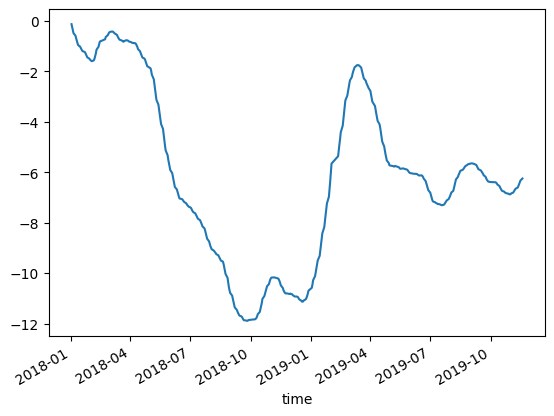

In [35]:
bt.data.groupby('time')['future_ret'].mean().cumsum().plot()

In [42]:
bt.performance_dc[fc_name]['daily_gross_ret']

,time,fac_upperline_10 1,fac_upperline_10 2,fac_upperline_10 3,fac_upperline_10 4,fac_upperline_10 5,fac_upperline_10 6,fac_upperline_10 7,fac_upperline_10 8,fac_upperline_10 9,fac_upperline_10 10,fac_upperline_10 10-1,ret
0,2018-01-02,-0.144748,-0.138846,-0.150521,-0.137040,-0.146121,-0.143836,-0.124526,-0.135819,-0.108856,-0.093948,0.025400,0.025400
1,2018-01-03,-0.127084,-0.132611,-0.133681,-0.140632,-0.145291,-0.124654,-0.126417,-0.120084,-0.103962,-0.086206,0.020439,0.020439
2,2018-01-04,-0.136237,-0.132840,-0.129052,-0.141915,-0.135397,-0.121377,-0.120352,-0.120272,-0.116207,-0.082103,0.027067,0.027067
3,2018-01-05,-0.128947,-0.117036,-0.124338,-0.120820,-0.112213,-0.103845,-0.116115,-0.098044,-0.108035,-0.083931,0.022508,0.022508
4,2018-01-08,-0.112232,-0.107101,-0.119028,-0.101568,-0.102116,-0.097499,-0.092388,-0.101989,-0.100432,-0.081488,0.015372,0.015372
...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,2019-11-12,0.059560,0.075532,0.069551,0.057431,0.058366,0.062497,0.060260,0.065094,0.066958,0.066078,0.003259,0.003259
452,2019-11-13,0.060327,0.078406,0.068755,0.071780,0.059856,0.075589,0.065585,0.070039,0.078714,0.063548,0.001611,0.001611
453,2019-11-14,0.063682,0.074162,0.077701,0.064599,0.064497,0.076217,0.071916,0.074688,0.088845,0.059972,-0.001855,-0.001855
454,2019-11-15,0.055562,0.049558,0.072618,0.075047,0.076960,0.060090,0.074625,0.066710,0.068379,0.054911,-0.000325,-0.000325


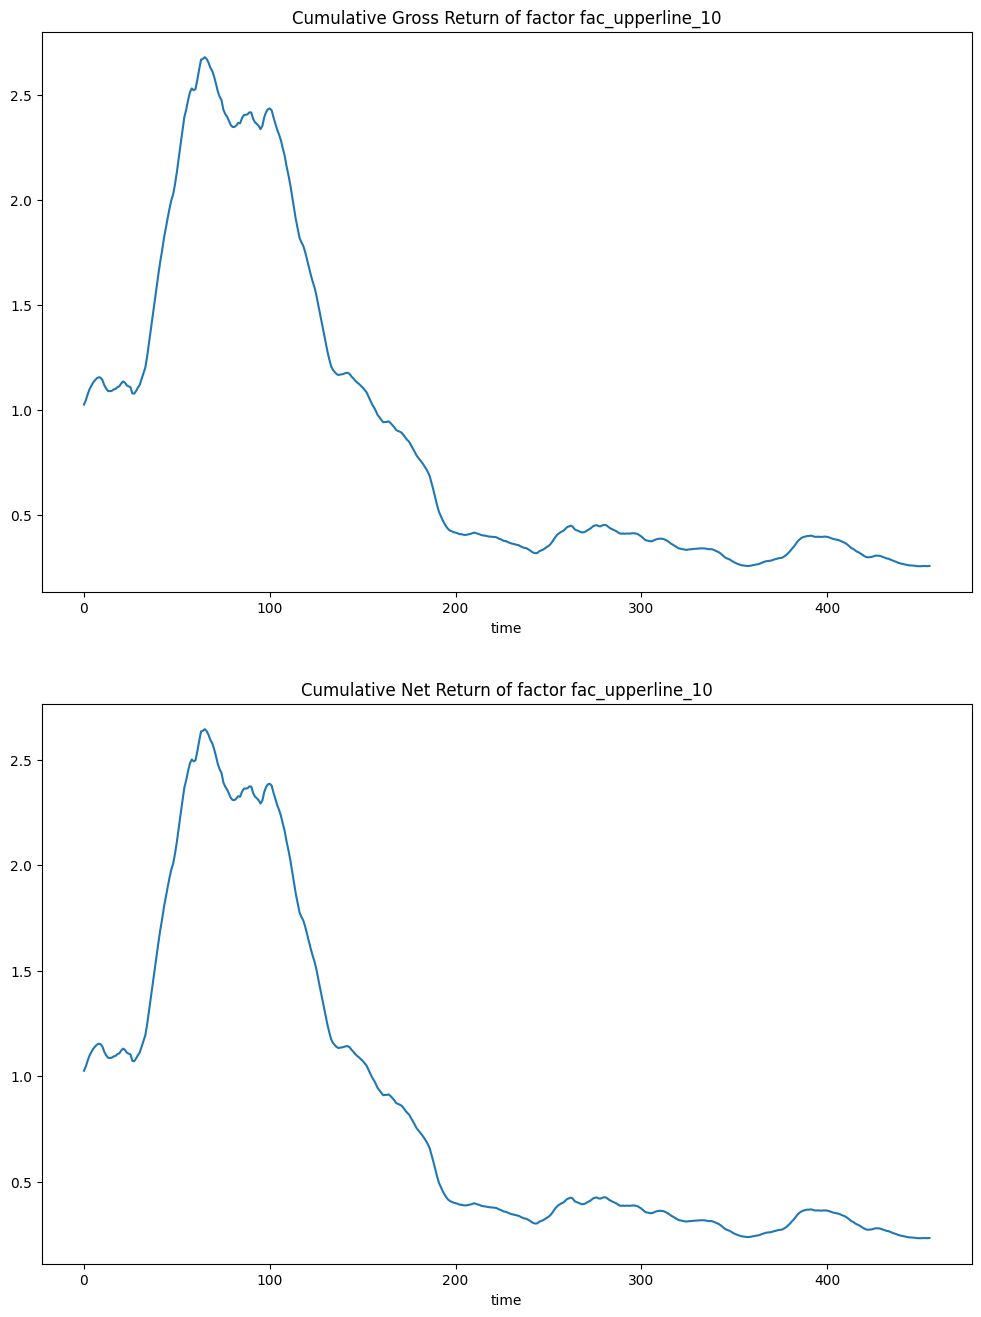

In [39]:
bt.plot_nav(fc_name)

In [21]:
bt.data['fac_winrate_30']

-7.887374308590211

In [22]:
bt.performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net Win Rate,Turnover,NumIC,RankIC,NumICIR,RankICIR,Average Instrument Count,Factor Name,Factor Freq,Fee
year,,,,,,,,,,,,,,,,,,,,,
2018,-2.916160,-2.949566,0.358502,0.358443,-8.134296,-8.228818,-9.429350,-9.534732,0.965497,0.966374,...,0.322314,0.530250,0.017632,-0.060096,0.177868,-0.567792,2470,fac_cumret_1_50,1d,0.00025
2019,-0.988189,-1.023058,0.364734,0.364798,-2.709343,-2.804448,-4.552557,-4.694634,0.883908,0.885801,...,0.384977,0.553472,0.043061,-0.052830,0.465197,-0.517740,2652,fac_cumret_1_50,1d,0.00025
all,-2.013615,-2.047706,0.366095,0.366087,-5.500248,-5.593490,-7.375754,-7.492807,0.994426,0.994683,...,0.351648,0.541121,0.029536,-0.056694,0.304987,-0.544992,2552,fac_cumret_1_50,1d,0.00025
2018,-3.118886,-3.144728,0.432100,0.432027,-7.217978,-7.279003,-8.532958,-8.601981,0.977016,0.977460,...,0.367769,0.410182,0.016580,-0.062784,0.145072,-0.489938,2470,fac_cumret_1_100,1d,0.00025
2019,-0.145105,-0.169326,0.246774,0.246826,-0.588005,-0.686013,-1.092730,-1.274752,0.580912,0.585627,...,0.446009,0.384464,0.052920,-0.052598,0.669802,-0.746698,2652,fac_cumret_1_100,1d,0.00025
all,-1.726764,-1.751847,0.369197,0.369181,-4.677084,-4.745229,-5.532521,-5.611979,0.983655,0.984216,...,0.404396,0.398143,0.033592,-0.058016,0.332963,-0.551652,2552,fac_cumret_1_100,1d,0.00025
2018,-3.344842,-3.370129,0.366051,0.366033,-9.137630,-9.207169,-10.504840,-10.581920,0.976103,0.976572,...,0.307054,0.401383,0.002771,-0.064678,0.027594,-0.600845,2470,fac_cumret_2_50,1d,0.00025
2019,-1.472005,-1.497675,0.360746,0.360815,-4.080447,-4.150806,-6.906738,-7.025537,0.904213,0.905392,...,0.352113,0.407455,0.027474,-0.056958,0.303780,-0.555042,2652,fac_cumret_2_50,1d,0.00025
all,-2.466176,-2.491643,0.367923,0.367943,-6.702967,-6.771811,-8.905058,-8.995203,0.996851,0.996962,...,0.328194,0.404232,0.014361,-0.061056,0.148731,-0.579984,2552,fac_cumret_2_50,1d,0.00025


In [3]:
# data = get_stock_price(frequency=fc_freq,
#                 start_time=start_time,
#                 end_time=end_time,
#                 from_database=True)

In [196]:
instrument_id = get_stock_info(from_database=True)['instrument_id'].to_list()
start_time=20190101
if not start_time:
    mongo_operator = {
        '$and': [
            {'time': {'$lte': end_time}},
            {'instrument_id': {"$in": instrument_id}}
        ]}
else:
    mongo_operator = {
        '$and': [
            {'time': {'$gte': start_time}},
            {'time': {'$lte': end_time}},
            {'instrument_id': {"$in": instrument_id}}
        ]}

In [201]:
data = get_stock_price(frequency='1m',
                start_time='20190101',
                end_time='20210101',
                from_database=True)

In [204]:
data['ret'] = data.groupby('instrument_id')['close'].transform(lambda x: x.pct_change())

In [208]:
data.loc[data['ret'] == data['ret'].max()]

,time,instrument_id,open,high,low,close,volume,ret
5035,2020-09-15 13:49:00,300216,0.2,0.21,0.19,0.21,1183400,0.105263


In [275]:
data.groupby('instrument_id')['ret'].mean() * 4 * 60 * 240

instrument_id
000018     12.274731
000939           NaN
002220     14.376793
002509     19.383667
002604           NaN
300028      2.770190
300090     39.666986
300104     23.981864
300156           NaN
300216   -220.750457
300431           NaN
600069           NaN
600074           NaN
600175           NaN
600240           NaN
600485     -0.966640
600677           NaN
600747     17.428885
601558     23.713104
Name: ret, dtype: float64

In [220]:
data['ret'].min() * 4 * 60 * 240

-10981.294964028772

In [249]:
data.loc[data['instrument_id'] == '002509']['ret'].mean() * 4 * 60 * 240

19.383666647273746

In [250]:
data.loc[data['instrument_id'] == '002509']['ret'].sum() * (4 * 60 * 240 / 1970)

19.373827222579695

In [276]:
(data.loc[data['instrument_id'] == '002509']['ret']).sum()

0.6626117991055903

In [273]:
((data.loc[data['instrument_id'] == '002509']['ret']) + 1).prod() - 1

-0.16666666666667074

In [224]:
data.loc[data['instrument_id'] == '300216'].iloc[600:650]

,time,instrument_id,open,high,low,close,volume,ret
5009,2020-09-15 13:23:00,300216,0.17,0.18,0.17,0.18,137100,0.058824
5010,2020-09-15 13:24:00,300216,0.17,0.18,0.17,0.17,765782,-0.055556
5011,2020-09-15 13:25:00,300216,0.17,0.18,0.17,0.17,55600,0.000000
5012,2020-09-15 13:26:00,300216,0.17,0.18,0.17,0.18,204800,0.058824
5013,2020-09-15 13:27:00,300216,0.17,0.18,0.17,0.17,176700,-0.055556
5014,2020-09-15 13:28:00,300216,0.17,0.18,0.17,0.18,172900,0.058824
5015,2020-09-15 13:29:00,300216,0.18,0.18,0.18,0.18,102700,0.000000
5016,2020-09-15 13:30:00,300216,0.18,0.18,0.17,0.17,74500,-0.055556
5017,2020-09-15 13:31:00,300216,0.17,0.18,0.17,0.17,95800,0.000000
5018,2020-09-15 13:32:00,300216,0.17,0.18,0.17,0.17,77200,0.000000


In [215]:
data.loc[data['instrument_id'] == '300216']

,time,instrument_id,open,high,low,close,volume,ret
4409,2020-08-05 09:55:00,300216,3.43,3.43,3.43,3.43,100,NaN
4410,2020-08-06 09:39:00,300216,3.09,3.09,3.09,3.09,40300,-0.099125
4411,2020-08-07 11:07:00,300216,2.78,2.78,2.78,2.78,100,-0.100324
4412,2020-08-07 14:39:00,300216,2.78,2.78,2.78,2.78,100,0.000000
4413,2020-08-11 09:47:00,300216,2.25,2.25,2.25,2.25,2000,-0.190647
...,...,...,...,...,...,...,...,...
5100,2020-09-15 14:54:00,300216,0.19,0.20,0.19,0.20,491010,0.052632
5101,2020-09-15 14:55:00,300216,0.20,0.20,0.19,0.19,208400,-0.050000
5102,2020-09-15 14:56:00,300216,0.19,0.20,0.19,0.20,63526,0.052632
5103,2020-09-15 14:57:00,300216,0.20,0.21,0.19,0.19,86800,-0.050000


In [4]:
# data = get_factor_value(data, fc_name_list, n_jobs)

In [5]:
# data.to_pickle(path)

In [6]:
data = pd.read_pickle(path)

In [7]:
data

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,0.666667,NaN,NaN
1,2018-01-02,300070,17.43,17.58,17.26,17.41,151887,NaN,NaN,NaN,NaN,NaN,NaN,0.882353,0.882353,NaN,NaN
2,2018-01-02,600315,36.41,36.50,35.88,36.01,48246,NaN,NaN,NaN,NaN,NaN,NaN,0.169811,0.169811,NaN,NaN
3,2018-01-02,603037,26.78,26.80,26.41,26.61,4656,NaN,NaN,NaN,NaN,NaN,NaN,0.054054,0.054054,NaN,NaN
4,2018-01-02,601579,11.77,11.89,11.73,11.85,9211,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253421,2019-12-31,002935,28.81,29.10,28.55,28.60,18827,-0.000810,-0.000797,-0.001064,-0.001018,-0.001848,-0.001831,3.358321,2.227867,0.5,0.500000
1253422,2019-12-31,600419,13.45,14.20,13.45,13.80,79946,0.000345,0.000265,0.000484,0.000009,0.000240,-0.000502,1.967989,1.331606,0.6,0.466667
1253423,2019-12-31,832149,3.39,3.71,3.30,3.64,16049,0.015942,0.010584,0.031092,0.020608,0.044273,0.029353,1.991216,1.785489,0.8,0.600000
1253424,2019-12-31,600790,3.40,3.41,3.37,3.40,68122,-0.001216,-0.000558,-0.002384,-0.001203,-0.003441,-0.001961,1.416667,1.280000,0.5,0.466667


In [8]:
data = get_future_ret(data, fc_freq, transaction_period, ret_freq, rfr)

In [9]:
data = cross_sectional_norm(data, fc_name_with_param_list)

In [10]:
fc_name = fc_name_with_param_list[0]
fc_name

'fac_cumret_1_50'

In [11]:
df = data.copy()
df_gross_ret, df_net_ret, df_n, df_turnover = \
    get_grouped_ret_and_turnover_for_one_factor(df, fc_name, portfolio_number, portfolio_method, fc_freq, fee)

In [1]:
get_nan_summary(df_gross_ret)

NameError: name 'get_nan_summary' is not defined

In [141]:
get_nan_summary(df_gross_ret)

time                    0
fac_cumret_1_50 1       0
fac_cumret_1_50 2       0
fac_cumret_1_50 3       0
fac_cumret_1_50 4       0
fac_cumret_1_50 5       0
fac_cumret_1_50 6       0
fac_cumret_1_50 7       0
fac_cumret_1_50 8       0
fac_cumret_1_50 9       0
fac_cumret_1_50 10      0
fac_cumret_1_50 10-1    0
ret                     0
dtype: int64

In [142]:
ret_col = [fc_name + ' ' + str(i) for i in range(1, portfolio_number + 1)] + \
            [f'{fc_name} {portfolio_number}-1', 'ret']
df_gross_ret = df_gross_ret.reset_index()
df_net_ret = df_net_ret.reset_index()
df_n = df_n.reset_index()
df_turnover = df_turnover.reset_index()

In [74]:
df.loc[df['instrument_id'] == '836414']

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
1495,2018-01-02,836414,7.25,7.25,7.22,7.22,20,NaN,NaN,NaN,NaN,NaN,NaN,-0.395686,-0.395686,NaN,NaN,7.2350,NaN
5573,2018-01-04,836414,7.04,7.04,6.94,6.94,30,-2.799029,-2.799029,NaN,NaN,NaN,NaN,-0.635454,-0.635454,NaN,NaN,6.9900,NaN
25512,2018-01-16,836414,7.10,7.10,7.10,7.10,10,-0.345909,-0.345909,-0.606758,-0.606758,NaN,NaN,-0.740492,-0.805657,NaN,NaN,7.1000,NaN
28668,2018-01-17,836414,6.86,6.89,6.86,6.88,11920,-0.843262,-0.843262,-0.233630,-0.233630,-1.407513,-1.407513,-0.681674,-0.814154,NaN,NaN,6.8725,NaN
32855,2018-01-19,836414,6.85,6.85,6.85,6.85,10,-0.918319,-0.918319,-0.670864,-0.670864,-0.590427,-0.590427,-0.711492,-0.910767,NaN,NaN,6.8500,NaN
70751,2018-02-12,836414,6.77,6.80,6.77,6.79,1000,-0.913200,-0.913200,-0.477948,-0.477948,-0.812924,-0.812924,-0.725769,-1.216852,NaN,NaN,6.7825,NaN
95582,2018-03-05,836414,6.90,6.90,6.90,6.90,10,-0.869809,-0.869809,-0.749025,-0.749025,-1.027970,-1.027970,-0.830864,-1.253190,NaN,NaN,6.9000,NaN
151976,2018-04-10,836414,6.86,7.00,6.47,6.92,7420,-0.766756,-0.769269,-0.501750,-0.494012,-0.806737,-0.794591,-0.689923,-1.174591,NaN,NaN,6.8125,NaN
160814,2018-04-16,836414,6.80,6.92,6.47,6.75,1283,-1.133147,-1.193384,-0.665752,-0.704538,-0.741925,-0.766848,-0.571161,-1.113020,NaN,NaN,6.7350,NaN
196909,2018-05-09,836414,7.03,7.03,7.03,7.03,20,-0.618386,-0.345534,-0.837432,-0.517301,-0.957117,-0.620169,-0.821424,-1.098783,-1.212028,NaN,7.0300,NaN


In [80]:
fc_col = fc_name

In [147]:
df.groupby('time')['fac_cumret_1_50'].mean()

time
2018-01-02             NaN
2018-01-03    3.512779e-17
2018-01-04    2.330041e-17
2018-01-05   -2.954440e-18
2018-01-08   -2.737599e-17
                  ...     
2019-12-25   -1.162189e-17
2019-12-26    9.761197e-18
2019-12-27    3.414217e-18
2019-12-30    1.164170e-17
2019-12-31   -3.907825e-18
Name: fac_cumret_1_50, Length: 487, dtype: float64

In [148]:
df1

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
2407,2018-01-03,300223,35.37,35.99,34.58,35.65,113539,-0.571284,-0.571284,NaN,NaN,NaN,NaN,-0.454712,-0.454712,NaN,NaN,35.3975,-0.299894
2408,2018-01-03,000852,9.90,10.49,9.90,10.33,171741,1.799849,1.799849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1550,-0.265788
2409,2018-01-03,000687,10.58,11.60,10.58,11.50,167883,3.968094,3.968094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0650,-0.148145
2410,2018-01-03,002240,14.78,14.95,14.78,14.89,42071,-0.317304,-0.317304,NaN,NaN,NaN,NaN,-0.112970,-0.112970,NaN,NaN,14.8500,0.014996
2411,2018-01-03,603966,16.66,16.93,16.48,16.76,17207,-0.860136,-0.860136,NaN,NaN,NaN,NaN,-0.361671,-0.361671,NaN,NaN,16.7075,-0.233434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4818,2018-01-03,002359,22.13,22.75,22.12,22.46,26897,-0.172597,-0.172597,NaN,NaN,NaN,NaN,3.366196,3.366196,NaN,NaN,22.3650,0.134206
4819,2018-01-03,600097,16.89,17.08,16.85,17.04,10549,-0.004985,-0.004985,NaN,NaN,NaN,NaN,-0.176872,-0.176872,NaN,NaN,16.9650,-0.189811
4820,2018-01-03,603656,31.96,31.96,31.40,31.83,4707,-0.417943,-0.417943,NaN,NaN,NaN,NaN,-0.537834,-0.537834,NaN,NaN,31.7875,-0.239715
4821,2018-01-03,600468,6.54,6.67,6.47,6.63,42553,0.268065,0.268065,NaN,NaN,NaN,NaN,0.375550,0.375550,NaN,NaN,6.5775,-0.235047


In [146]:
df1['fac_cumret_1_50'].mean()

3.623708789784025e-17

In [151]:
df1 = list(df.groupby('time'))[1][1]
df1['future_ret'].isna().value_counts()
df1['fac_cumret_1_50'].isna().value_counts()

fac_cumret_1_50
False    2402
True       14
Name: count, dtype: int64

In [ ]:
df1 = df1.dropna(subset=[fc_col, 'future_ret'])
df1['quantile_0'] = float('-inf')
for i in range(1, portfolio_number):
    df1[f'quantile_{i}'] = df1.groupby('time')[fc_col].transform(lambda x: x.quantile(i / portfolio_number))
df1[f'quantile_{portfolio_number}'] = float('inf')
for i in range(portfolio_number):
    

In [125]:
count = df.groupby('time').size()
count[3] = 9 
count[20] = 6
invaild_time_idx = count[count < portfolio_number].index.to_list()
invaild_time_idx

[Timestamp('2018-01-05 00:00:00'), Timestamp('2018-01-30 00:00:00')]

In [134]:
df[~df['time'].isin(invaild_time_idx)]

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,future_ret
0,2018-01-02,600981,5.75,5.79,5.69,5.78,19888,NaN,NaN,NaN,NaN,NaN,NaN,-0.335598,-0.335598,NaN,NaN,5.7525,-0.151828
1,2018-01-02,603926,27.00,27.35,27.00,27.30,7995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.1625,-0.156068
2,2018-01-02,300324,14.56,14.67,14.42,14.51,53695,NaN,NaN,NaN,NaN,NaN,NaN,-0.324868,-0.324868,NaN,NaN,14.5400,0.093036
3,2018-01-02,600243,6.86,6.89,6.81,6.88,9416,NaN,NaN,NaN,NaN,NaN,NaN,-0.341607,-0.341607,NaN,NaN,6.8600,-0.123333
4,2018-01-02,600741,29.69,29.70,27.60,28.33,346317,NaN,NaN,NaN,NaN,NaN,NaN,-0.395254,-0.395254,NaN,NaN,28.8300,-0.099530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253421,2019-12-31,300605,12.80,13.08,12.68,12.76,25394,-0.238326,-0.163342,-0.220543,-0.177324,-0.281546,-0.179633,-0.100471,-0.541312,0.782503,0.784770,12.8300,NaN
1253422,2019-12-31,603311,11.13,11.26,11.05,11.18,11332,0.244698,0.047732,0.285340,0.070534,0.310896,0.080795,-0.258357,-0.358106,-0.007444,-0.096426,11.1550,NaN
1253423,2019-12-31,000880,7.76,7.86,7.74,7.83,9107,-0.187058,-0.192428,-0.184853,-0.199816,-0.194598,-0.231739,-0.201260,-0.397232,1.572450,1.225367,7.7975,NaN
1253424,2019-12-31,600076,4.30,4.42,4.29,4.39,185037,-0.030087,-0.096852,-0.045573,-0.100833,-0.060910,-0.105013,-0.017982,-0.420399,0.782503,0.344172,4.3500,NaN


In [77]:
df.loc[df['future_ret'].isna()]['future_ret'].sum(skipna=False)

nan

In [67]:
df_gross_ret

,time,fac_cumret_1_50 1,fac_cumret_1_50 2,fac_cumret_1_50 3,fac_cumret_1_50 4,fac_cumret_1_50 5,fac_cumret_1_50 6,fac_cumret_1_50 7,fac_cumret_1_50 8,fac_cumret_1_50 9,fac_cumret_1_50 10,fac_cumret_1_50 10-1,ret
0,2018-01-03,-0.161759,-0.106562,-0.111126,-0.130473,-0.119171,-0.130845,-0.120261,-0.127104,-0.135026,-0.100275,0.030742,0.030742
1,2018-01-04,-0.150204,-0.136588,-0.122759,-0.111641,-0.115938,-0.128082,-0.118554,-0.129783,-0.114419,-0.094606,0.027799,0.027799
2,2018-01-05,-0.137442,-0.124726,-0.114361,-0.111890,-0.100484,-0.112346,-0.105811,-0.110405,-0.108944,-0.078169,0.029636,0.029636
3,2018-01-08,-0.122195,-0.119339,-0.112471,-0.091442,-0.099908,-0.108010,-0.089897,-0.089858,-0.092785,-0.076027,0.023084,0.023084
4,2018-01-09,-0.122675,-0.118397,-0.108467,-0.109677,-0.101039,-0.104437,-0.093250,-0.095311,-0.091926,-0.101200,0.010738,0.010738
...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,2019-12-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
482,2019-12-26,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
483,2019-12-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
484,2019-12-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [66]:
df_gross_ret['fac_cumret_1_50 1'].tail(40)

446    0.074982
447    0.077191
448    0.050320
449    0.075975
450    0.113565
451    0.119305
452    0.118075
453    0.102446
454    0.118570
455    0.000000
456    0.000000
457    0.000000
458    0.000000
459    0.000000
460    0.000000
461    0.000000
462    0.000000
463    0.000000
464    0.000000
465    0.000000
466    0.000000
467    0.000000
468    0.000000
469    0.000000
470    0.000000
471    0.000000
472    0.000000
473    0.000000
474    0.000000
475    0.000000
476    0.000000
477    0.000000
478    0.000000
479    0.000000
480    0.000000
481    0.000000
482    0.000000
483    0.000000
484    0.000000
485    0.000000
Name: fac_cumret_1_50 1, dtype: float64

In [47]:
data1['fac_cumret_1_50'].std(skipna=True)

0.9998060648113458

In [46]:
data1['fac_cumret_1_50'].dropna().std()

0.9998060648113458

In [11]:
get_nan_summary(data)

time                 0.000000
instrument_id        0.000000
open                 0.000000
high                 0.000000
low                  0.000000
close                0.000000
volume               0.000000
fac_cumret_1_50      0.002302
fac_cumret_1_100     0.002302
fac_cumret_2_50      0.004588
fac_cumret_2_100     0.004588
fac_cumret_3_50      0.006868
fac_cumret_3_100     0.006868
fac_upperline_10     0.003669
fac_upperline_30     0.003025
fac_winrate_10       0.020471
fac_winrate_30       0.065330
transaction_price    0.000000
future_ret           0.069781
dtype: float64

In [24]:
bt.ts_performance_summary

,Gross Return,Net Return,Gross Vola,Net Vola,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee
year,,,,,,,,,,,,,,,,,,,,,
2018,-1.573298,-110.418200,0.174140,1.828817,-9.034683,-60.376844,-11.155633,-60.376844,0.790028,1.0,...,1727.696867,NaN,-0.041095,-0.048510,132.118760,523661.0,NaN,fac_cumret_1_50,1d,0.00025
2019,-0.768054,-174.505690,0.201707,4.543571,-3.807776,-38.407170,-5.879160,-38.407170,0.738755,1.0,...,2757.740249,NaN,-0.016500,-0.009434,136.761106,561108.0,NaN,fac_cumret_1_50,1d,0.00025
all,-1.171619,-142.386901,0.189880,4.003748,-6.170312,-35.563406,-8.556973,-35.563406,0.926711,1.0,...,NaN,2241.512419,-0.026587,-0.037266,36158.966667,NaN,NaN,fac_cumret_1_50,1d,0.00025
2018,-1.737061,-110.581963,0.220299,1.834877,-7.885001,-60.266700,-9.761599,-60.266700,0.840948,1.0,...,1727.696867,NaN,-0.045879,-0.042001,132.118760,523661.0,NaN,fac_cumret_1_100,1d,0.00025
2019,-0.480702,-174.218338,0.140484,4.512958,-3.421761,-38.604028,-5.414482,-38.604028,0.552897,1.0,...,2757.740249,NaN,-0.010328,-0.003740,136.761106,561108.0,NaN,fac_cumret_1_100,1d,0.00025
all,-1.110352,-142.325635,0.188831,3.980682,-5.880151,-35.754086,-7.362559,-35.754086,0.893143,1.0,...,NaN,2241.512419,-0.025215,-0.032042,36158.966667,NaN,NaN,fac_cumret_1_100,1d,0.00025
2018,-1.706070,-110.550972,0.174178,1.828466,-9.794996,-60.461042,-11.899630,-60.461042,0.806603,1.0,...,1727.696867,NaN,-0.044680,-0.051088,132.118760,523661.0,NaN,fac_cumret_2_50,1d,0.00025
2019,-0.915774,-174.653410,0.202850,4.546470,-4.514529,-38.415167,-6.662165,-38.415167,0.756474,1.0,...,2757.740249,NaN,-0.019759,-0.011265,136.761106,561108.0,NaN,fac_cumret_2_50,1d,0.00025
all,-1.311847,-142.527130,0.190440,4.005543,-6.888492,-35.582474,-9.318577,-35.582474,0.938946,1.0,...,NaN,2241.512419,-0.029911,-0.039367,36158.966667,NaN,NaN,fac_cumret_2_50,1d,0.00025


In [22]:
bt.performance_summary.columns

Index(['Gross Return', 'Net Return', 'Gross Vola', 'Net Vola', 'Gross Sharpe',
       'Net Sharpe', 'Gross Sortino', 'Net Sortino', 'Gross MaxDD',
       'Net MaxDD', 'Gross Calmar', 'Net Calmar', 'Gross Win Rate_x',
       'Net Win Rate', 'Gross Win Rate_y', 'Turnover', 'Turnover', 'NumIC',
       'RankIC', 'NumICIR', 'RankICIR', 'Average Instrument Count',
       'Factor Name', 'Factor Freq', 'Fee'],
      dtype='object')

In [30]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_30']

In [31]:
bt.data

,time,instrument_id,open,high,low,close,volume,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_30,transaction_price,ret
69655,2018-02-12,603517,35.45,35.86,34.54,35.50,5262,0.152149,0.152149,0.092966,0.092966,-0.083658,-0.083658,-0.087019,-0.121227,0.022027,0.210198,35.3375,-0.000366
69656,2018-02-12,600240,7.82,7.96,7.71,7.84,45871,0.322923,0.322923,0.274318,0.274318,0.346917,0.346917,0.149644,0.338660,0.022027,0.210198,7.8325,0.071343
69657,2018-02-12,603829,14.24,14.80,14.24,14.79,24467,-0.284543,-0.284543,-0.325890,-0.325890,-0.226360,-0.226360,0.289346,0.159414,0.022027,0.665627,14.5175,0.239557
69658,2018-02-12,600741,25.00,25.51,24.68,25.32,114160,0.256816,0.256816,0.435235,0.435235,0.528603,0.528603,-0.585036,-0.687884,-0.885642,-1.156089,25.1275,-0.054178
69659,2018-02-12,600874,10.38,10.66,10.38,10.61,78177,-0.469190,-0.469190,-0.820441,-0.820441,-0.989079,-0.989079,-0.340843,-0.375391,0.929696,0.210198,10.5075,0.283691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168191,2019-11-18,002033,5.81,5.87,5.80,5.86,20070,0.054188,0.084910,0.043125,0.065946,0.028016,0.050587,-0.000910,-0.221266,0.651044,0.896322,5.8350,0.066283
1168192,2019-11-18,601801,5.03,5.08,4.99,5.03,33683,-0.702575,-0.543994,-0.697144,-0.557152,-0.657522,-0.546391,-0.259855,-0.395509,-1.476272,-1.510700,5.0325,0.087305
1168193,2019-11-18,002546,3.74,3.82,3.69,3.81,49523,-0.295016,-0.451082,-0.353684,-0.494075,-0.392673,-0.529527,-0.078751,-0.479196,-0.058062,-0.708359,3.7650,0.100139
1168194,2019-11-18,600256,3.19,3.22,3.17,3.20,119346,-0.159701,-0.222699,-0.135183,-0.207469,-0.136693,-0.206009,-0.252264,-0.342694,-0.767167,-1.109530,3.1950,0.033519


In [33]:
df_gross_ret_ts, df_net_ret_ts, df_turnover_ts = get_ts_ret_and_turnover(bt.data, 'fac_cumret_1_50', 0.00025)

In [34]:
df_turnover_ts

,fac_cumret_1_50
time,
2018-02-12,0.000000
2018-02-13,963.555297
2018-02-14,1677.708752
2018-02-22,1316.692829
2018-02-23,1133.193980
...,...
2019-11-12,1997.741554
2019-11-13,1690.880601
2019-11-14,1654.157062


In [40]:
ret_col = ['fac_cumret_1_50']
df = df_turnover_ts.reset_index().copy()
df = df.dropna(subset=ret_col)
df = df.sort_values(by='time', ascending=True)
df['year'] = pd.to_datetime(df['time']).dt.year

turnover_year = df.groupby('year')[ret_col].mean()
turnover_all = (df[ret_col].mean()).to_frame('all').T
turnover = pd.concat([turnover_year, turnover_all])
turnover.index.name = 'year'

In [39]:
turnover

,fac_cumret_1_50,fac_cumret_1_50
year,,
2018,1727.696867,NaN
2019,2757.740249,NaN
all,NaN,2241.512419


In [29]:
bt.ts_performance_dc['fac_cumret_1_50']['annualized_turnover']

,fac_cumret_1_50,fac_cumret_1_50
year,,
2018,1727.696867,NaN
2019,2757.740249,NaN
all,NaN,2241.512419


In [12]:
for fc_name in bt.fc_name_with_param_list:
    df_gross_ret, df_net_ret, df_n, df_turnover = \
            get_grouped_ret_and_turnover_for_one_factor(bt.data, fc_name, 10, 'longshort', '1d', 0.00025)
    if len(df_net_ret.dropna()) == 0:
        break

In [23]:
portfolio_number = 10
fc_name = 'fac_winrate_10'
ret_col = [fc_name + ' ' + str(i) for i in range(1, portfolio_number + 1)] + \
              [f'{fc_name} {portfolio_number}-1', 'ret']

In [30]:
def get_annualized_win_rate(Data: pd.DataFrame,
                            ret_col: Union[str, list]):
    """
    Get win rate, which is the ratio of profitable trades.
    """
    if isinstance(ret_col, str):
        ret_col = [ret_col]
    df = Data.copy()
    df = df.sort_values(by='time', ascending=True)

    df['year'] = pd.to_datetime(df['time']).dt.year

    win_rate_list = []
    for col in ret_col:
        win_rate_list.append(df.groupby('year')[col].apply(lambda x: len(x[x > 0]) / len(x)))
    win_rate_year = pd.concat(win_rate_list, axis=1)
    
    # win_rate_all = pd.Series(len(df[df[ret_col] > 0]) / len(df), index=['all']]
    # print((df[ret_col].apply(lambda x: len(x[x > 0]) / len(x))))
    # print(ret_col)
    win_rate_all = (df[ret_col].apply(lambda x: len(x[x > 0]) / len(x))).to_frame('all').T
    win_rate = pd.concat([win_rate_year, win_rate_all])
    win_rate.index.name = 'year'

    return win_rate

In [31]:
get_annualized_win_rate(df_net_ret.reset_index(), ret_col)

,fac_winrate_10 1,fac_winrate_10 2,fac_winrate_10 3,fac_winrate_10 4,fac_winrate_10 5,fac_winrate_10 6,fac_winrate_10 7,fac_winrate_10 8,fac_winrate_10 9,fac_winrate_10 10,fac_winrate_10 10-1,ret
year,,,,,,,,,,,,
2018,0.172897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.182243,0.420561,0.420561
2019,0.483568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.422535,0.450704,0.450704
all,0.327869,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.302108,0.435597,0.435597


In [24]:
df = df_net_ret.reset_index().copy()
df = df.dropna()
df = df.sort_values(by='time', ascending=True)

df['year'] = pd.to_datetime(df['time']).dt.year
win_rate_list = []
for col in ret_col:
    win_rate_list.append(df.groupby('year')[col].apply(lambda x: len(x[x > 0]) / len(x)))
win_rate_year = pd.concat(win_rate_list, axis=1)

In [29]:
df_net_ret

,fac_winrate_10 1,fac_winrate_10 2,fac_winrate_10 3,fac_winrate_10 4,fac_winrate_10 5,fac_winrate_10 6,fac_winrate_10 7,fac_winrate_10 8,fac_winrate_10 9,fac_winrate_10 10,fac_winrate_10 10-1,ret
time,,,,,,,,,,,,
2018-02-12,0.101544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.093295,-0.004125,-0.004125
2018-02-13,0.115851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044953,-0.035885,-0.035885
2018-02-14,0.102373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048186,-0.027624,-0.027624
2018-02-22,0.065774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037869,-0.014312,-0.014312
2018-02-23,0.064005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046898,-0.008987,-0.008987
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-12,0.089804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048360,-0.021247,-0.021247
2019-11-13,0.101292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.053057,-0.024367,-0.024367
2019-11-14,0.070755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.067965,-0.002005,-0.002005


In [28]:
pd.Series(len(df[df[ret_col] > 0]) / len(df), index=['all'])

ZeroDivisionError: division by zero

In [25]:
win_rate_year

,fac_winrate_10 1,fac_winrate_10 2,fac_winrate_10 3,fac_winrate_10 4,fac_winrate_10 5,fac_winrate_10 6,fac_winrate_10 7,fac_winrate_10 8,fac_winrate_10 9,fac_winrate_10 10,fac_winrate_10 10-1,ret
year,,,,,,,,,,,,


In [9]:
df_net_ret['fac_winrate_30 2'].isna().value_counts()

fac_winrate_30 2
True     399
False     28
Name: count, dtype: int64

In [11]:
df_net_ret

,fac_winrate_30 1,fac_winrate_30 2,fac_winrate_30 3,fac_winrate_30 4,fac_winrate_30 5,fac_winrate_30 6,fac_winrate_30 7,fac_winrate_30 8,fac_winrate_30 9,fac_winrate_30 10,fac_winrate_30 10-1,ret
time,,,,,,,,,,,,
2018-02-12,0.117257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079699,-0.018779,-0.018779
2018-02-13,0.101653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060646,-0.020758,-0.020758
2018-02-14,0.103202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045592,-0.029024,-0.029024
2018-02-22,0.079818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041024,-0.019727,-0.019727
2018-02-23,0.076650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041794,-0.017646,-0.017646
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-12,0.100685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,-0.029074,-0.029074
2019-11-13,0.100671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041840,-0.029584,-0.029584
2019-11-14,0.097624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045317,-0.026532,-0.026532


In [5]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_30']

In [6]:
pd.Series(, index=['all']).to_frame('all').T

,all
all,


In [ ]:
df_gross_ret, df_net_ret, df_n, df_turnover = \
        get_grouped_ret_and_turnover_for_one_factor(bt.data, bt.fc_name_with_param_list[0], 10, 'longshort', '1d', 0.00025)

In [ ]:
def get_annualized_turnover(Data: pd.DataFrame,
                            ret_col: Union[str, list]):
    """

    :param Data:
    :param ret_col:
    :return:
    """
    if isinstance(ret_col, str):
        ret_col = [ret_col]
    for col in ['time'] + ret_col:
        assert col in Data.columns, f'Data does not contain column {col}.'
    df = Data.copy()
    df = df.dropna()
    df = df.sort_values(by='time', ascending=True)
    df['year'] = pd.to_datetime(df['time']).dt.year

    turnover_year = df.groupby('year')[ret_col].mean()
    turnover_all = (df[ret_col].mean()).to_frame('all').T
    turnover = pd.concat([turnover_year, turnover_all])
    turnover.index.name = 'year'

    return turnover

In [ ]:
get_annualized_turnover(df_turnover_ts, fc_col)

In [ ]:
fc_col

In [ ]:
get_annualized_turnover

In [ ]:
df_turnover_ts = df_turnover_ts.reset_index()

In [ ]:
def get_annualized_ts_ic_and_t_corr(Data: pd.DataFrame,
                                    fc_col: str,
                                    ret_freq: int):
    """

    :param Data:
    :param fc_col:
    :param ret_freq:
    :return:
    """
    for col in ['time', 'instrument_id', 'ret', fc_col]:
        assert col in Data.columns, f'df does not contain columns {col}.'

    df = Data.copy()
    df = df.sort_values(by='instrument_id')
    df['year'] = pd.to_datetime(df['time']).dt.year
    ic_ts_year = df.groupby('year')[fc_col].corr(df['ret'], method='pearson')
    ic_ts_all = pd.Series(df[fc_col].corr(df['ret'], method='pearson'), index=['all'])
    ic_ts = pd.concat([ic_ts_year, ic_ts_all]).to_frame('TS IC')

    rank_ic_ts_year = df.groupby('year')[fc_col].corr(df['ret'], method='spearman')
    rank_ic_ts_all = pd.Series(df[fc_col].corr(df['ret'], method='spearman'), index=['all'])
    rank_ic_ts = pd.concat([rank_ic_ts_year, rank_ic_ts_all]).to_frame('TS RankIC')

    ic_ts = pd.concat([ic_ts, rank_ic_ts], axis=1)

    t_corr_year = df.groupby('year')['ret'].apply(lambda x: np.sqrt(x.size / ret_freq))
    t_corr_all = pd.Series(len(df) / ret_freq, index=['all'])
    t_corr = pd.concat([t_corr_year, t_corr_all]).to_frame('T-corr')

    return ic_ts, t_corr

In [ ]:
annualized_ic_ts, annualized_tcorr_ts = get_annualized_ts_ic_and_t_corr(bt.data, 'fac_cumret_2_50', 30)

In [ ]:
annualized_ic_ts

In [ ]:
bt.data

In [ ]:
bt.data.set_index(['time', 'instrument_id']).unstack(level=1).diff().abs().fillna(0).mean(axis=1).to_frame('a')

In [ ]:
def get_ts_ret_and_turnover(Data: pd.DataFrame,
                            fc_col: Union[str, list],
                            fee: float = 0.00025):
    # time series gross ret and net ret
    # time series way of calculating ret and turnover is simpler
    # todo: 最后的performance中加入这个时序指标
    if isinstance(fc_col, str):
        fc_col = [fc_col]
    for col in ['time', 'instrument_id', 'ret'] + fc_col:
        assert col in Data.columns, f'Data does not contain column {col}.'

    df = Data.copy()
    df = df.dropna()
    df = df.set_index(['time', 'instrument_id'])
    df_gross_ret_ts = pd.DataFrame(df[fc_col].values * df[['ret']].values,
                                   index=df.index,
                                   columns=fc_col)
    df_gross_ret_ts = df_gross_ret_ts.groupby('time').mean()
    # the main difference between ts-turnover and cr-turnover is that ts-turnover takes time-cross-section mean here
    df_turnover_ts = df.unstack(level=1).diff().abs().fillna(0).mean(axis=1).to_frame(fc_col)
    df_net_ret_ts = pd.DataFrame(df_gross_ret_ts.values - (df_turnover_ts * fee).values,
                                 index=df_gross_ret_ts.index,
                                 columns=fc_col)

    return df_gross_ret_ts, df_net_ret_ts, df_turnover_ts

In [ ]:
fc_col = ['fac_cumret_2_50']
fee = 0.00025
df = bt.data.copy()
df = df.dropna()
df = df.set_index(['time', 'instrument_id'])
df_gross_ret_ts = pd.DataFrame(df[fc_col].values * df[['ret']].values,
                                index=df.index,
                                columns=fc_col)
df_gross_ret_ts = df_gross_ret_ts.groupby('time').mean()
# the main difference between ts-turnover and cr-turnover is that ts-turnover takes time-cross-section mean here
df_turnover_ts = df.unstack(level=1).diff().abs().fillna(0).mean(axis=1).to_frame()
df_turnover_ts.columns = fc_col
df_net_ret_ts = pd.DataFrame(df_gross_ret_ts.values - (df_turnover_ts * fee).values,
                                index=df_gross_ret_ts.index,
                                columns=fc_col)

# return df_gross_ret_ts, df_net_ret_ts, df_turnover_ts

In [ ]:
df1 = df.unstack(level=1).diff().abs().fillna(0).mean(axis=1)

In [ ]:
df_turnover_ts

In [ ]:
pd.DataFrame(df[fc_col].values * df[['ret']].values,
                                index=df.index,
                                columns=fc_col).groupby('time').mean()

In [ ]:
df_gross_ret_ts = pd.DataFrame(df[fc_col].values * df[['ret']].values,
                                index=df.index,
                                columns=fc_col)
df_gross_ret_ts = df_gross_ret_ts.groupby('time').mean()

In [ ]:
df.unstack(level=1).diff().abs().fillna(0).mean(axis=1).to_frame(fc_col)

In [5]:
df_gross_ret_ts, df_net_ret_ts, df_turnover_ts = get_ts_ret_and_turnover(bt.data, 'fac_cumret_2_50', 0.00025)

In [6]:
get_annualized_ret(df_net_ret_ts.reset_index(), 'fac_cumret_2_50')

,fac_cumret_2_50
year,
2018,-110.550972
2019,-174.653410
all,-142.527130


In [ ]:
df_gross_ret_ts

In [ ]:
df_net_ret_ts

In [ ]:
df_gross_ret_ts

In [ ]:
df_turnover_ts

In [ ]:
df_net_ret_ts

In [ ]:
df_gross_ret_ts = df_gross_ret_ts.reset_index()
gross_annualized_ret_ts = get_annualized_ret(df_gross_ret_ts, ret_col, interest_method)

In [ ]:
get_ts_ret_and_turnover(df, fc_name, fee)

In [ ]:
class fac_cumret:
    param_range = {'a': [1, 2, 3],
                   'b': [50, 100]}

    @staticmethod
    def operate(Data: pd.DataFrame, **kwargs):
        hash_tb = {chr(i): 0 for i in range(97, 123)}
        for key, value in kwargs.items():
            hash_tb[key] = value
        a = int(hash_tb['a'])
        b = int(hash_tb['b'])

        df = Data.copy()
        df['ret'] = df['close'].pct_change(a)
        df['mom'] = df['ret'].rolling(b, 1).mean()

        return df['mom']

In [ ]:
parameters = eval('fac_cumret').param_range
fc_name = fac_cumret.__name__

In [ ]:
fc_name_with_param_list = [join_fc_name_and_parameter(fc_name, parameter) for parameter in iterdict(parameters)]
fc_name_with_param = fc_name_with_param_list[0]

In [ ]:
fc_name = ''
fc_name
for x in fc_name_with_param.split('_'):
    if x.isalpha():
        if len(fc_name) == 0:
            fc_name = x
        else:
            fc_name = fc_name + '_' + x
    if x.isdigit():
        parameter

fc_name

In [ ]:
fc_name_with_param.split('_')

In [ ]:
iterdict(parameters)

In [ ]:
fc_class = fac_cumret

In [ ]:
fc_class.__name__

In [ ]:
fc_name = 'fac_cumret'
parameters = eval(fc_name).param_range

In [ ]:
iterdict(parameters)
parameter = iterdict(parameters)[0]

In [ ]:
fc_name + '_' + '_'.join([str(value) for _, value in parameter.items()])

In [ ]:
fac_cumret.operate(pd.DataFrame(), **parameter)

In [ ]:
def iterdict(parameter):
    para_keys = parameter.keys()
    para_list = []
    for key in para_keys:
        para_list.append(parameter[key])
    para_rows = list(product(*para_list))
    para_rows = [dict(zip(para_keys, x)) for x in para_rows]
    
    return para_rows


def join_fc_name_and_parameter(fc_name, parameter):
    
    return fc_name + '_' + '_'.join([str(value) for _, value in parameter.items()])

In [ ]:
[join_fc_name_and_parameter(fc_name, parameter) for parameter in iterdict(parameters)]